# 01. EDA & Feature Engineering

Heart Disease コンペの探索的データ分析と特徴量エンジニアリング。

- データの概要確認・分布チェック
- カテゴリ変数のクロス集計
- 相関行列
- 91特徴量の作成（スケーリング、ビニング、頻度エンコーディング、ターゲット統計量）
- 前処理済みデータをCSV出力（02で使用）

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    FunctionTransformer, RobustScaler, OrdinalEncoder, KBinsDiscretizer
)

RANDOM_STATE = 42

## 1. データ読み込み

In [ ]:
# データセットのパスを入力（データはご自身で取得してください） 
trainval = pd.read_csv("../dataset/raw/train.csv")
test = pd.read_csv("../dataset/raw/test.csv")

# 目的変数を 0/1 に変換
ymap = {"Presence": 1, "Absence": 0}
trainval["target"] = trainval["Heart Disease"].map(ymap)
trainval = trainval.drop(columns=["Heart Disease"])

print(f"trainval: {trainval.shape}")
print(f"test:     {test.shape}")
print(f"\nTarget distribution:\n{trainval['target'].value_counts(normalize=True)}")

trainval: (630000, 15)
test:     (270000, 14)

Target distribution:
target
0    0.55166
1    0.44834
Name: proportion, dtype: float64


In [3]:
cat_cols = [
    'Sex', 'Chest pain type', 'FBS over 120', 'EKG results',
    'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium',
]
num_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']

## 2. EDA

### 2.1 数値特徴量の分布

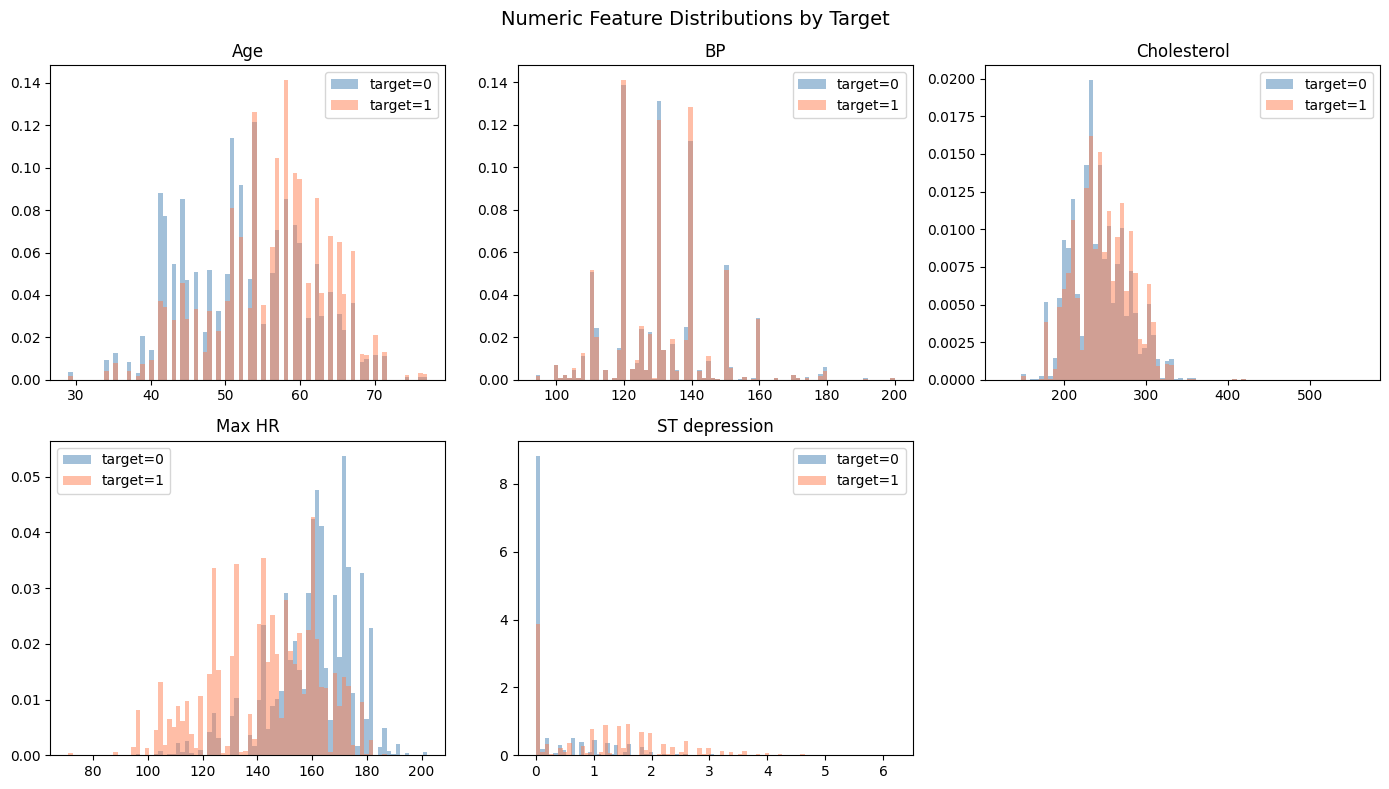

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, color in [(0, "steelblue"), (1, "coral")]:
        subset = trainval[trainval["target"] == label][col]
        axes[i].hist(subset, bins=80, alpha=0.5, density=True, color=color,
                     label=f"target={label}")
    axes[i].set_title(col)
    axes[i].legend()

axes[-1].axis("off")
plt.suptitle("Numeric Feature Distributions by Target", fontsize=14)
plt.tight_layout()
plt.show()

### 2.2 カテゴリ特徴量の分布

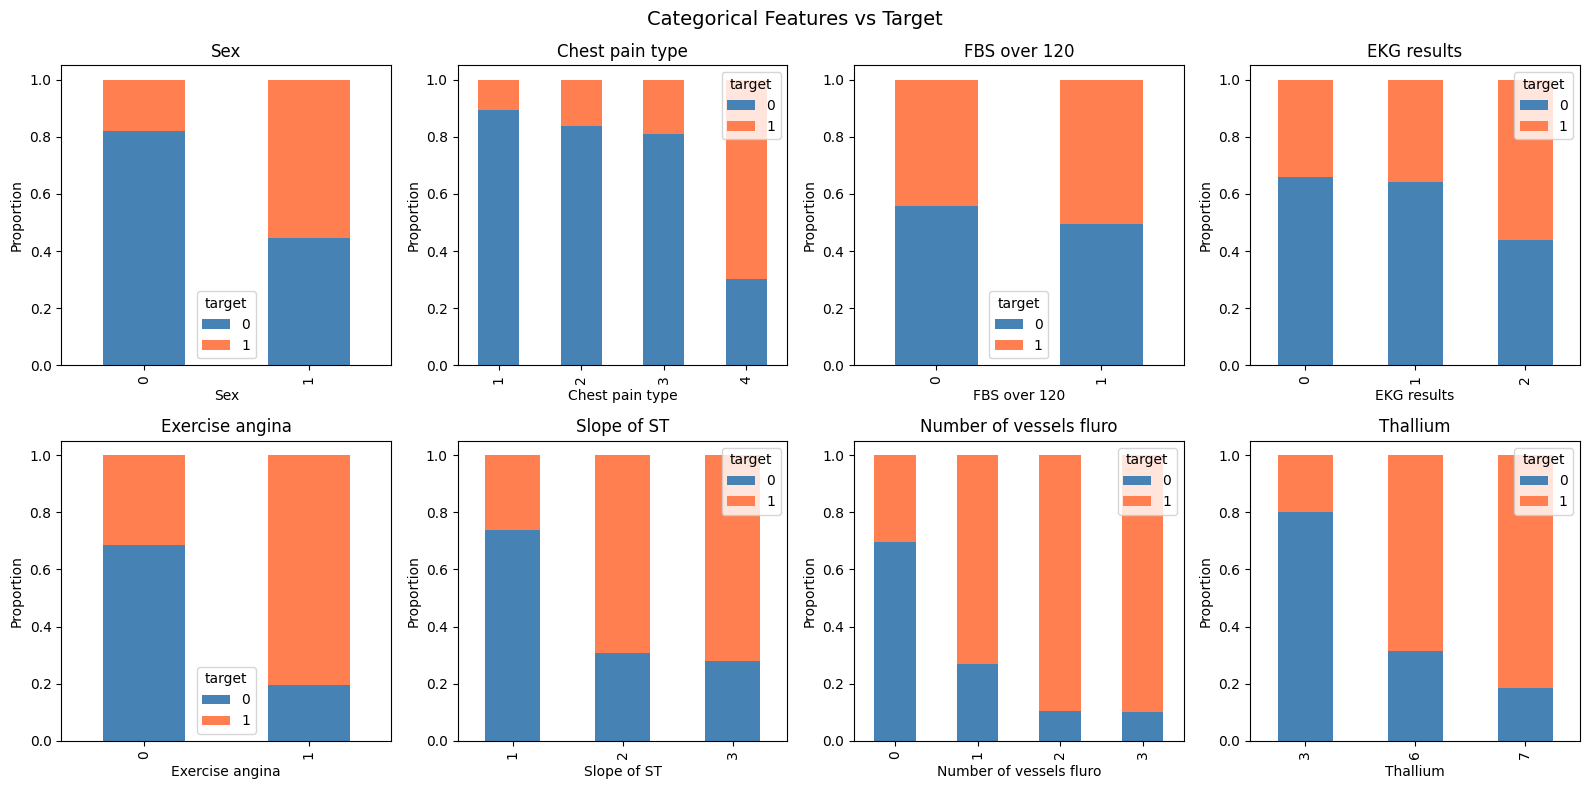

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(trainval[col], trainval["target"], normalize="index")
    ct.plot(kind="bar", stacked=True, ax=axes[i], color=["steelblue", "coral"])
    axes[i].set_title(col)
    axes[i].set_ylabel("Proportion")
    axes[i].legend(title="target", labels=["0", "1"])

plt.suptitle("Categorical Features vs Target", fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
for col in cat_cols:
    print(f"--- {col} ---")
    print(trainval[col].value_counts())
    print()

--- Sex ---
Sex
1    450283
0    179717
Name: count, dtype: int64

--- Chest pain type ---
Chest pain type
4    329179
3    197278
2     74941
1     28602
Name: count, dtype: int64

--- FBS over 120 ---
FBS over 120
0    579608
1     50392
Name: count, dtype: int64

--- EKG results ---
EKG results
0    320116
2    308562
1      1322
Name: count, dtype: int64

--- Exercise angina ---
Exercise angina
0    457553
1    172447
Name: count, dtype: int64

--- Slope of ST ---
Slope of ST
1    358293
2    256215
3     15492
Name: count, dtype: int64

--- Number of vessels fluro ---
Number of vessels fluro
0    445862
1    106978
2     54303
3     22857
Name: count, dtype: int64

--- Thallium ---
Thallium
3    372286
7    246748
6     10966
Name: count, dtype: int64



### 2.3 相関行列

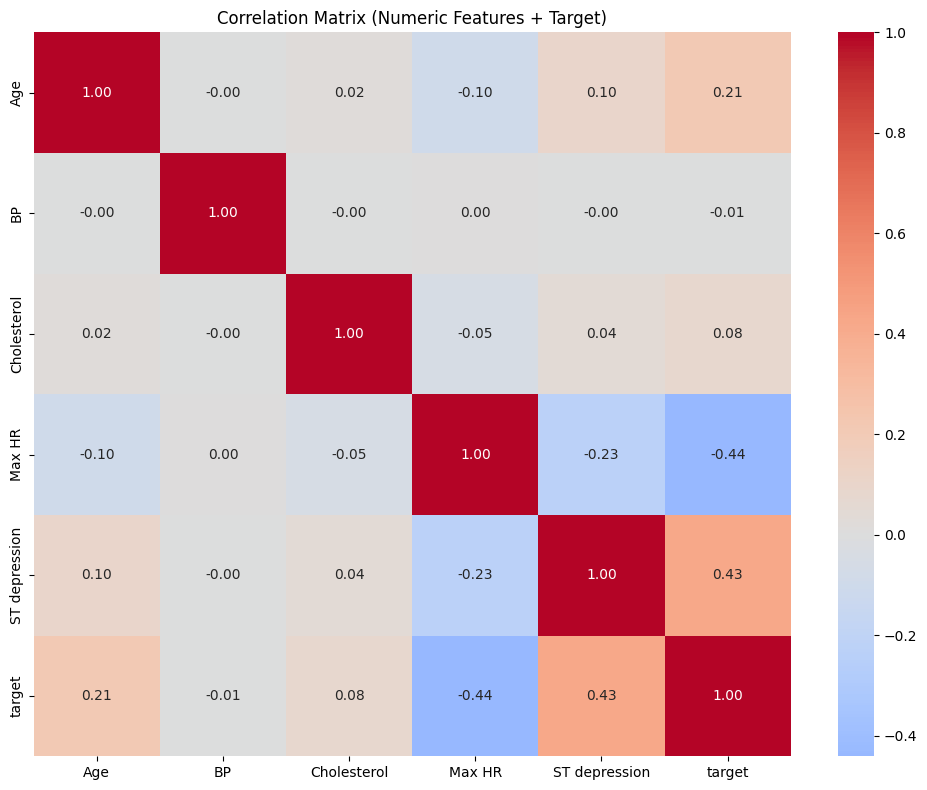

In [7]:
plt.figure(figsize=(10, 8))
corr = trainval[num_cols + ["target"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix (Numeric Features + Target)")
plt.tight_layout()
plt.show()

### 2.4 Train / Val / Test の分布比較

In [8]:
# 先にtrain/valを分割してから分布を比較する
ss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=RANDOM_STATE)
train_idx, val_idx = next(ss.split(trainval, trainval["target"]))
train = trainval.iloc[train_idx].reset_index(drop=True)
val = trainval.iloc[val_idx].reset_index(drop=True)
train_labels = train.pop("target")
val_labels = val.pop("target")

print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")

Train: 567000, Val: 63000, Test: 270000


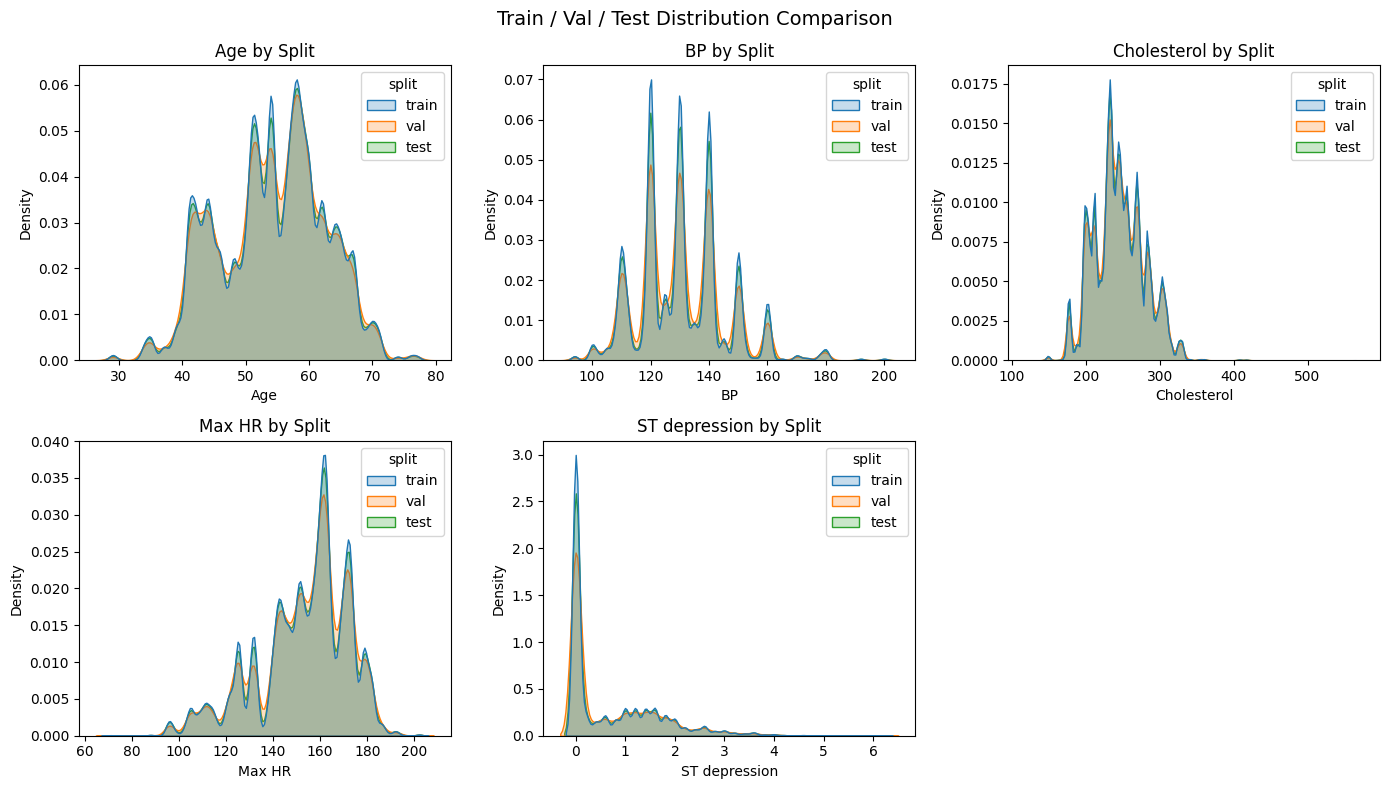

In [9]:
df_plot = pd.concat([
    train[num_cols].assign(split="train"),
    val[num_cols].assign(split="val"),
    test[num_cols].assign(split="test"),
], ignore_index=True)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.kdeplot(data=df_plot, x=col, hue="split", common_norm=False,
                fill=True, ax=axes[i])
    axes[i].set_title(f"{col} by Split")

axes[-1].axis("off")
plt.suptitle("Train / Val / Test Distribution Comparison", fontsize=14)
plt.tight_layout()
plt.show()

## 3. 特徴量エンジニアリング

trainval全体の統計量を分割前に辞書として計算しておく。  
こうすることで test に適用する際もリークしない。

In [10]:
# trainval全体でターゲット統計量の辞書を作成（分割前に計算済み）
global_stats = {
    "mean": trainval["target"].mean(),
    "median": trainval["target"].median(),
    "count": trainval["target"].count(),
    "std": trainval["target"].std(),
    "skew": trainval["target"].skew(),
}

freq_encodings = {}
stats_means = {}
stats_medians = {}
stats_conts = {}
stats_stds = {}
stats_skews = {}

for col in trainval.columns[1:-1]:  # id, target を除く
    freq_encodings[col] = trainval[col].value_counts(normalize=True).to_dict()
    stats_means[col] = trainval.groupby(col)["target"].mean().to_dict()
    stats_medians[col] = trainval.groupby(col)["target"].median().to_dict()
    stats_conts[col] = trainval.groupby(col)["target"].count().to_dict()
    stats_stds[col] = trainval.groupby(col)["target"].std().to_dict()
    stats_skews[col] = trainval.groupby(col)["target"].agg(lambda x: x.skew()).to_dict()

print(f"Statistics computed on {len(trainval)} rows.")

Statistics computed on 630000 rows.


In [11]:
# ヘルパー関数

def frq_enc(X, features):
    """頻度エンコーディング"""
    X_freq = pd.DataFrame()
    for c in features:
        X_freq[c] = X[c].map(freq_encodings[c]).astype(float).fillna(0)
    return X_freq


def target_stats(X, features, st_type):
    """ターゲット統計量（mean, median, std, skew, count）"""
    stats_map = {
        'mean': stats_means,
        'median': stats_medians,
        'count': stats_conts,
        'std': stats_stds,
        'skew': stats_skews,
    }
    stats = stats_map[st_type]
    X_stat = pd.DataFrame()
    for c in features:
        X_stat[c] = X[c].map(stats[c]).fillna(global_stats.get(st_type, 0))
    return X_stat

In [12]:
# 前処理パイプライン

kbins_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('kbins', KBinsDiscretizer(n_bins=10, strategy='uniform',
                               encode='ordinal', random_state=RANDOM_STATE)),
    ('kbins_cast', FunctionTransformer(
        lambda X: X.astype(np.uint8), feature_names_out='one-to-one'))
])

frq_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('frq', FunctionTransformer(
        func=lambda x: frq_enc(x, x.columns), feature_names_out='one-to-one'))
])

mean_pipeline = Pipeline([('mean', FunctionTransformer(
    func=lambda x: target_stats(x, x.columns, 'mean'), feature_names_out='one-to-one'))])
median_pipeline = Pipeline([('median', FunctionTransformer(
    func=lambda x: target_stats(x, x.columns, 'median'), feature_names_out='one-to-one'))])
std_pipeline = Pipeline([('std', FunctionTransformer(
    func=lambda x: target_stats(x, x.columns, 'std'), feature_names_out='one-to-one'))])
skew_pipeline = Pipeline([('skew', FunctionTransformer(
    func=lambda x: target_stats(x, x.columns, 'skew'), feature_names_out='one-to-one'))])
count_pipeline = Pipeline([('count', FunctionTransformer(
    func=lambda x: target_stats(x, x.columns, 'count'), feature_names_out='one-to-one'))])

preprocessing = ColumnTransformer([
    ("cluster", kbins_pipeline, num_cols),
    ("frqc", frq_pipeline, cat_cols),
    ("mean", mean_pipeline, num_cols + cat_cols),
    ("median", median_pipeline, num_cols + cat_cols),
    ("std", std_pipeline, num_cols + cat_cols),
    ("skew", skew_pipeline, num_cols + cat_cols),
    ("count", count_pipeline, num_cols + cat_cols),
]).set_output(transform='pandas')

print("Preprocessing pipeline defined.")

Preprocessing pipeline defined.


In [13]:
# パイプライン適用
train_transformed = preprocessing.fit_transform(train)
val_transformed = preprocessing.transform(val)
test_transformed = preprocessing.transform(test)

print(f"Transformed features: {train_transformed.shape[1]}")
train_transformed.head(3)

Transformed features: 78


,cluster__Age,cluster__BP,cluster__Cholesterol,cluster__Max HR,cluster__ST depression,frqc__Sex,frqc__Chest pain type,frqc__FBS over 120,frqc__EKG results,frqc__Exercise angina,...,count__Max HR,count__ST depression,count__Sex,count__Chest pain type,count__FBS over 120,count__EKG results,count__Exercise angina,count__Slope of ST,count__Number of vessels fluro,count__Thallium
0,6,4,1,7,0,0.285265,0.313140,0.920013,0.508121,0.726275,...,27914,314939,179717,197278,579608,320116,457553,358293,445862,372286
1,6,3,3,8,0,0.714735,0.118954,0.920013,0.489781,0.726275,...,13004,20474,450283,74941,579608,308562,457553,358293,106978,372286
2,5,1,4,6,0,0.714735,0.522506,0.920013,0.489781,0.273725,...,12114,314939,450283,329179,579608,308562,172447,256215,54303,246748


In [14]:
# パイプライン出力 + 生カテゴリ列（ネイティブのカテゴリ処理用）を結合
train_raw_cat = train[cat_cols].reset_index(drop=True)
val_raw_cat = val[cat_cols].reset_index(drop=True)
test_raw_cat = test[cat_cols].reset_index(drop=True)

train_features = pd.concat([train_transformed.reset_index(drop=True), train_raw_cat], axis=1)
val_features = pd.concat([val_transformed.reset_index(drop=True), val_raw_cat], axis=1)
test_features = pd.concat([test_transformed.reset_index(drop=True), test_raw_cat], axis=1)

# カテゴリ列のインデックス
cat_feature_indices = list(range(train_transformed.shape[1], train_transformed.shape[1] + len(cat_cols)))

print(f"Total features: {train_features.shape[1]} (transformed {train_transformed.shape[1]} + {len(cat_cols)} raw categorical)")
print(f"cat_feature_indices: {cat_feature_indices}")

Total features: 86 (transformed 78 + 8 raw categorical)
cat_feature_indices: [78, 79, 80, 81, 82, 83, 84, 85]


## 4. 前処理済みデータの保存

02_modeling.ipynb で読み込んで使用する。

In [15]:
train_features.to_csv("../dataset/processed/train_features.csv", index=False)
val_features.to_csv("../dataset/processed/val_features.csv", index=False)
test_features.to_csv("../dataset/processed/test_features.csv", index=False)

train_labels.to_csv("../dataset/processed/train_labels.csv", index=False, header=True)
val_labels.to_csv("../dataset/processed/val_labels.csv", index=False, header=True)

# cat_feature_indices も保存
pd.Series(cat_feature_indices).to_csv("../dataset/processed/cat_feature_indices.csv", index=False, header=False)

print("Saved:")
print(f"  train_features: {train_features.shape}")
print(f"  val_features:   {val_features.shape}")
print(f"  test_features:  {test_features.shape}")
print(f"  train_labels:   {train_labels.shape}")
print(f"  val_labels:     {val_labels.shape}")

Saved:
  train_features: (567000, 86)
  val_features:   (63000, 86)
  test_features:  (270000, 86)
  train_labels:   (567000,)
  val_labels:     (63000,)
